# Matching Process Trees

### Build graph $G$ and find the connected components (process trees)
1. From the ```process_uber_summary``` table, build an ```igraph``` directed graph $G$ where each edge is of the form: ```parent PID --> child PID```
2. Get all (weak) connected components from $G$ -- those are the ```process trees``` (with one exception where a loop is present, which we drop), and save those in the **Trees** object
    * 99.98% of components are of size 2 (1,111,052  out of 1,111,278) ...
    * 210 process trees contain between 3 and 10k nodes
    * 15 have more then 10k nodes


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from collections import Counter
import igraph as ig
import gzip
import pickle
from functools import partial
from scipy.spatial import distance

## our matching algorithm
import sys
import os
sys.path.insert(0,os.path.abspath('../Matching'))
import igraph_io as igio
import fast_match as fm  ## fast version
import needleman_wunsch_tree as nwt ## slower, more flexibility for scoring functions

## several utility functions
from acme_util import *


# Build process trees from the ```process_uber_summary``` table


In [3]:
process_summary = pd.read_parquet("Data/process_uber_summary.parquet", columns=['pid_hash', 'parent_pid_hash', 'process_name', 'user_name', 'red_team'] )
process_summary.head()


,pid_hash,parent_pid_hash,process_name,user_name,red_team
0,A86DB324303BBC24B4C279909AC5AD00,B066C89E8047845304C38E8BEE22AD90,powershell.exe,ACME\user10,1
1,C194ECED319F84EC8DAED02EE44FCE63,450735D5CC2CCEC4C8B12EC8818120E8,wmic.exe,None,0
2,FA50BB30E957D73120420F46B18AE167,450735D5CC2CCEC4C8B12EC8818120E8,wmic.exe,None,0
3,5803C60CEB8387DFA7ADA3E5E75E88FF,6FB634509A57999E72BCAFA74A8FFF29,wmic.exe,None,0
4,3BD26DAC90333D99453E9F506A514B1B,6FB634509A57999E72BCAFA74A8FFF29,wmic.exe,None,0


In [4]:
## we'll use those throughout
dct_username = dict(zip(process_summary.pid_hash,process_summary.user_name))
dct_label = dict(zip(process_summary.pid_hash,process_summary.red_team))
dct_processname = dict(zip(process_summary.pid_hash,process_summary.process_name))


In [5]:
%%time
Trees = extract_process_trees(process=process_summary, uid='pid_hash', parent_uid='parent_pid_hash',
                              min_tree_size=3, max_tree_size=100000, 
                              extra={'process_name':'process','user_name':'user','red_team':'redteam'})


CPU times: user 13.9 s, sys: 534 ms, total: 14.5 s
Wall time: 14.5 s


In [6]:
## for plotting - red_team nodes in red
Trees.graph.vs['label_color'] = 'black'
Trees.graph.vs['color'] = 'black'
for v in Trees.graph.vs:
    if dct_label.get(v['uid'],0)>0:
        v['label_color']='red'
        v['color']='red'

# EDA

In [7]:
len(Trees)

224

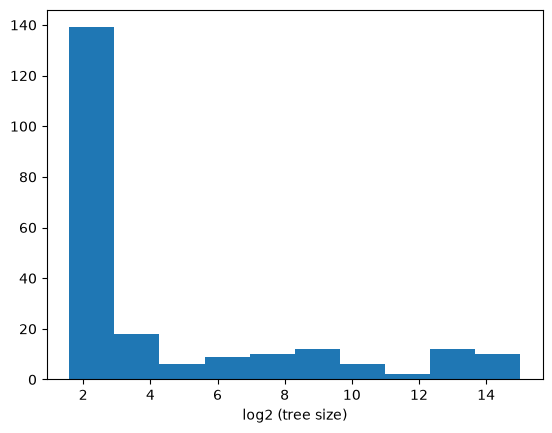

In [8]:
plt.hist([np.log2(x) for x in Trees.sizes()])
plt.xlabel('log2 (tree size)');


In [9]:
Trees.graph.vs[0]

igraph.Vertex(<igraph.Graph object at 0x7097c8241a50>, 0, {'uid': 'B066C89E8047845304C38E8BEE22AD90', 'tree': 0, 'tree_size': 23835, 'process': 'unknown', 'user': None, 'redteam': 1, 'label_color': 'red', 'color': 'red'})

### List all subtrees with known root process name


In [10]:
df_trees = pd.DataFrame()
for t in range(len(Trees)):
    _df = acme_list_process_subtrees(Trees.subgraph(t), dct_username, dct_label)
    _df.insert(loc=0, column='tree', value=t)
    df_trees = pd.concat([df_trees,_df])
df_trees


,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,redteam
0,0,2,ssm-agent-worker.exe,15904,3,15889,0,0,0,0
1,0,6,svchost.exe,769,3,761,0,0,0,0
2,0,39,ssm-document-worker.exe,4,2,3,0,0,0,0
3,0,52,svchost.exe,24,2,23,0,0,0,0
4,0,56,services.exe,22933,6,21039,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1,183,4,conhost.exe,4,4,1,0,0,0,0
0,186,0,conhost.exe,3,3,1,0,0,0,0
0,188,2,conhost.exe,3,3,1,0,0,0,0
0,206,1,conhost.exe,3,3,1,0,0,0,0


In [11]:
df_trees[ (df_trees.layers==5) & (df_trees.redteam>0) & (df_trees.nodes==10) ]

,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,redteam
192,2,12347,notepad++.exe,10,5,5,0,0,0,3
25,27,89,cmd.exe,10,5,6,0,0,0,6


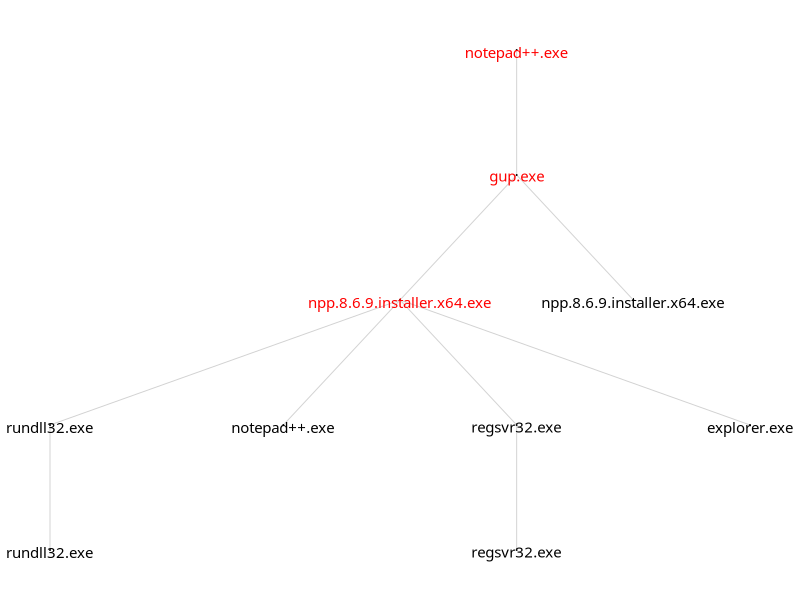

In [12]:
sg = acme_get_bfs_subtree(Trees, 2, 12347)
ig.plot(sg, target="_temp.png", bbox=(800,600), layout=sg.layout_reingold_tilford(), margin=50,
        vertex_size=1,
        vertex_label=sg.vs['process'],
        vertex_label_size=15,
        edge_color='lightgrey', edge_arrow_size=0)    
Image("_temp.png")


# Matching Experiment #1 -  top hits using various weight functions

* we select deep trees with up to 500 nodes (for display purpose)
* we compare "red trees" (with some redteam label) to "black trees"
* (optional) we report matches with at least one redteam label on the red tree matching path

We define different weight functions:

* default: exact match (between process names)
* redblack: exact match but only between redteam and non-readteam
* invfreq: exact match weighted by each process' inverse frequency (log scale)
* embed: exact match weighted by the process' distance in embedded space (built from numerical features)


In [14]:
## extract the subtrees
_df = df_trees[ (df_trees.layers>=7) & (df_trees.nodes<=500) ]
_trees = _df.tree.tolist()
_roots = _df.root.tolist()
TreeData_label = np.array(_df.redteam>0)
TreeData = []
for (t,r) in zip(_trees,_roots):
    sg = acme_get_bfs_subtree(Trees, t, r) 
    TreeData.append(igio.igraph_to_treedata(sg, phi_name='uid'))
Counter(TreeData_label)

Counter({np.False_: 144, np.True_: 32})

### (a) default weight

This is the default with a binary score of 1 if the process names coincide, 0 otherwise.


In [15]:
## default weights
def _def(a, b, _process):
    return int(_process[a]==_process[b])
weight = partial(_def, _process=dct_processname)

best_pair = run_redblack_match(TreeData, TreeData_label, weight, dct_label, min_red_nodes=1)

Score: 8.0


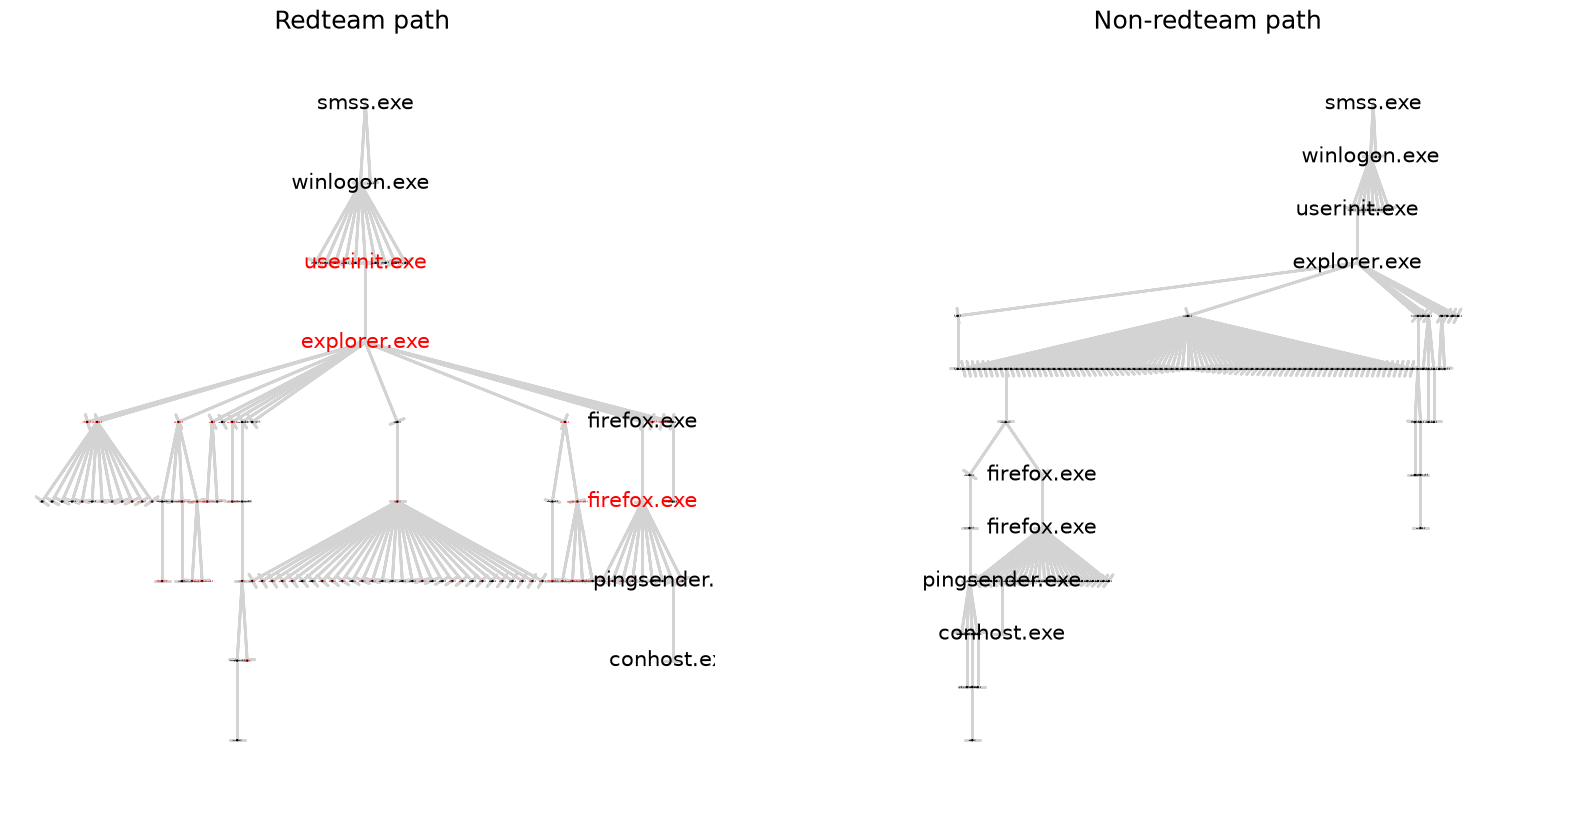

In [16]:
## plot best result
sg_red = acme_get_bfs_subtree(Trees, _trees[best_pair[0]], _roots[best_pair[0]]) 
sg_black = acme_get_bfs_subtree(Trees, _trees[best_pair[1]], _roots[best_pair[1]]) 
_sg_red = igio.igraph_to_treedata(sg_red, phi_name='uid')
_sg_black = igio.igraph_to_treedata(sg_black, phi_name='uid')
match = nwt.align_trees_algorithm1(_sg_red, _sg_black, w=weight)
plot_path((sg_red,sg_black), match.path_internal, margin=(0,.14))
print('Score:',match.score)

### (b) redblack weight

A binary score of 1 if the process names coincide AND the labels (here, redteam) are different, 0 otherwise.


In [18]:
## redblack
def _rb(a, b, _process, _label):
    return int(_process[a]==_process[b])*(_label[a]!=_label[b])
weight = partial(_rb, _process=dct_processname, _label=dct_label)

best_pair = run_redblack_match(TreeData, TreeData_label, weight, dct_label, min_red_nodes=1)


Score: 6.0


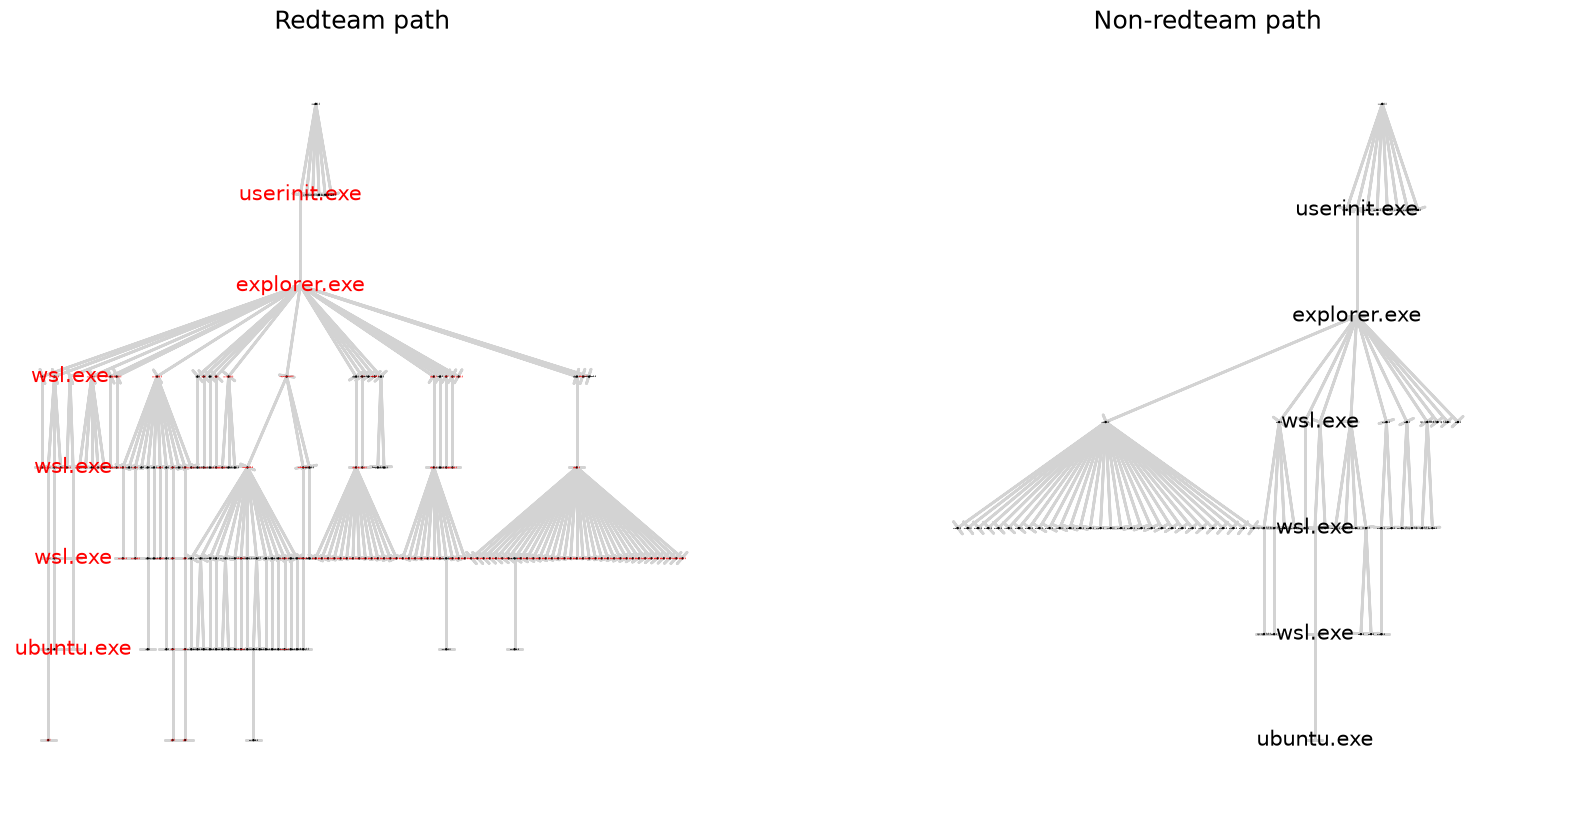

In [19]:
## plot best result
sg_red = acme_get_bfs_subtree(Trees, _trees[best_pair[0]], _roots[best_pair[0]]) 
sg_black = acme_get_bfs_subtree(Trees, _trees[best_pair[1]], _roots[best_pair[1]]) 
_sg_red = igio.igraph_to_treedata(sg_red, phi_name='uid')
_sg_black = igio.igraph_to_treedata(sg_black, phi_name='uid')
match = nwt.align_trees_algorithm1(_sg_red, _sg_black, w=weight)
plot_path((sg_red,sg_black), match.path_internal, margin=(0,.14))
print('Score:',match.score)

### (c) inverse fequency weight

A score in (0,1] inversely proportional (on log scale) to the process frequency if the process names coincide, 0 otherwise.


In [20]:
## inverse frequency
proc_counts = Counter([dct_processname.get(v,'') for v in Trees.graph.vs['uid']])
dct_invfreq = {k: float(1/np.log2(v+1)) for k, v in proc_counts.items()} ## max score of 1 when v==1
def _if(a, b, _process, _freq):
    return int(_process[a]==_process[b])*(_freq[_process[a]])
weight = partial(_if, _process=dct_processname, _freq=dct_invfreq)

best_pair = run_redblack_match(TreeData, TreeData_label, weight, dct_label, min_red_nodes=1)


Score: 1.8869611024856567


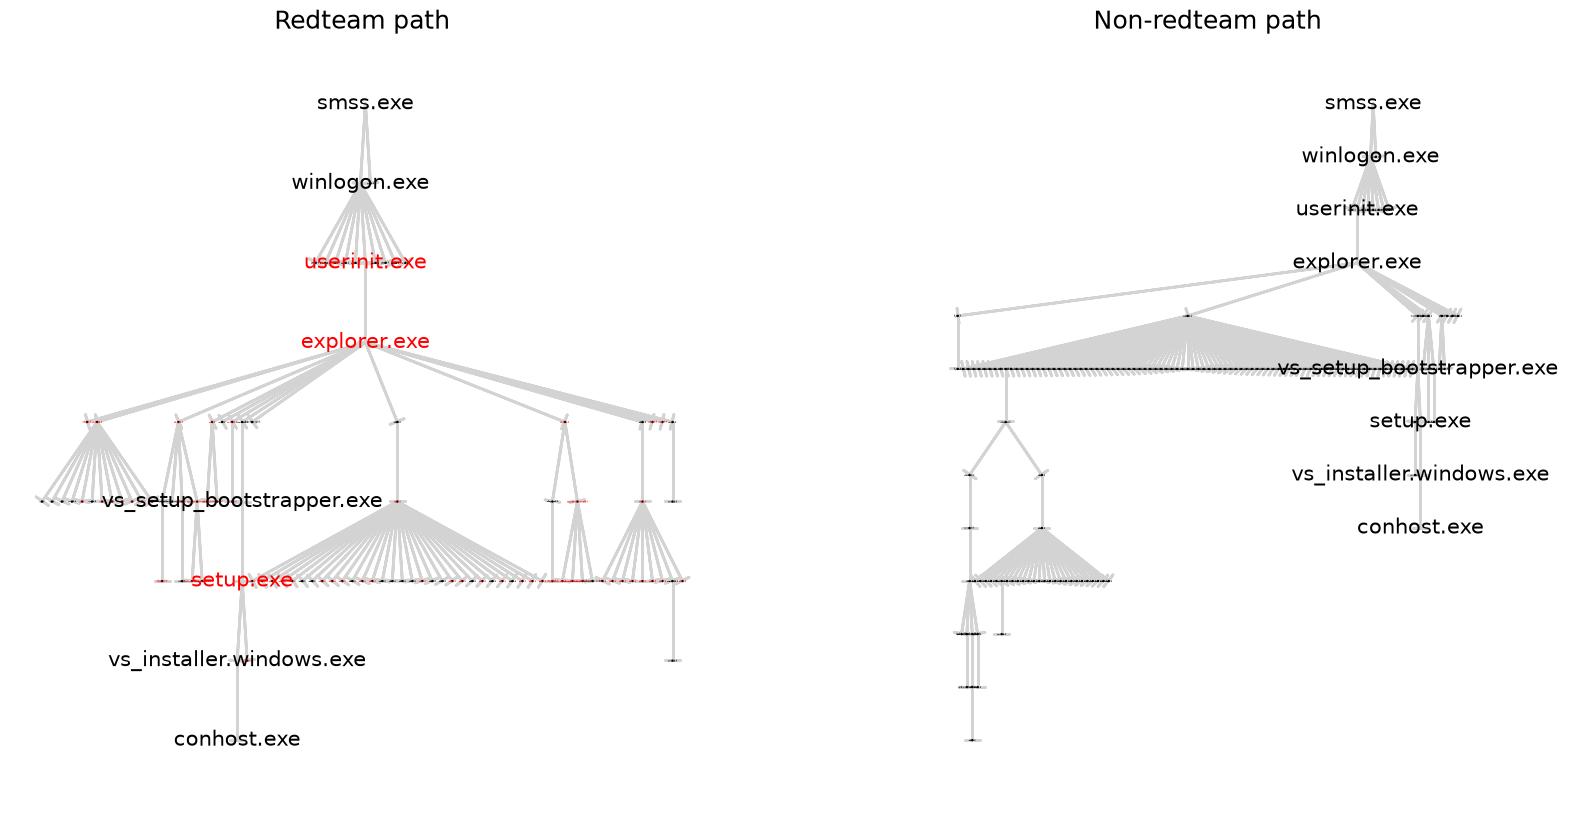

In [21]:
## plot best result
sg_red = acme_get_bfs_subtree(Trees, _trees[best_pair[0]], _roots[best_pair[0]]) 
sg_black = acme_get_bfs_subtree(Trees, _trees[best_pair[1]], _roots[best_pair[1]]) 
_sg_red = igio.igraph_to_treedata(sg_red, phi_name='uid')
_sg_black = igio.igraph_to_treedata(sg_black, phi_name='uid')
match = nwt.align_trees_algorithm1(_sg_red, _sg_black, w=weight)
plot_path((sg_red,sg_black), match.path_internal, margin=(0,.14))
print('Score:',match.score)

In [22]:
sum([x == 'vs_setup_bootstrapper.exe' for x in Trees.graph.vs['process']])


2

### (d) embedded weight

A score in (0,1] inversely proportional to the PID's Manhattan distance in embedded space if the process names coincide, 0 otherwise.


In [23]:
# embedded space
with gzip.open('Data/acme4_process_num_features_embedding_ecdf.pkl.gz', 'rb') as fp:
    embedding_ecdf = pickle.load(fp)
dim = len(next(iter(embedding_ecdf.values())))
def _es(a, b, _process, _emb):
    return int(_process[a]==_process[b])*(1-distance.cityblock(_emb[a],_emb[b])/dim)
    #return (1-distance.cityblock(_emb[a],_emb[b])/dim)
weight = partial(_es, _process=dct_processname, _emb=embedding_ecdf)

best_pair = run_redblack_match(TreeData, TreeData_label, weight, dct_label, min_red_nodes=1)


Score: 7.826830863952637


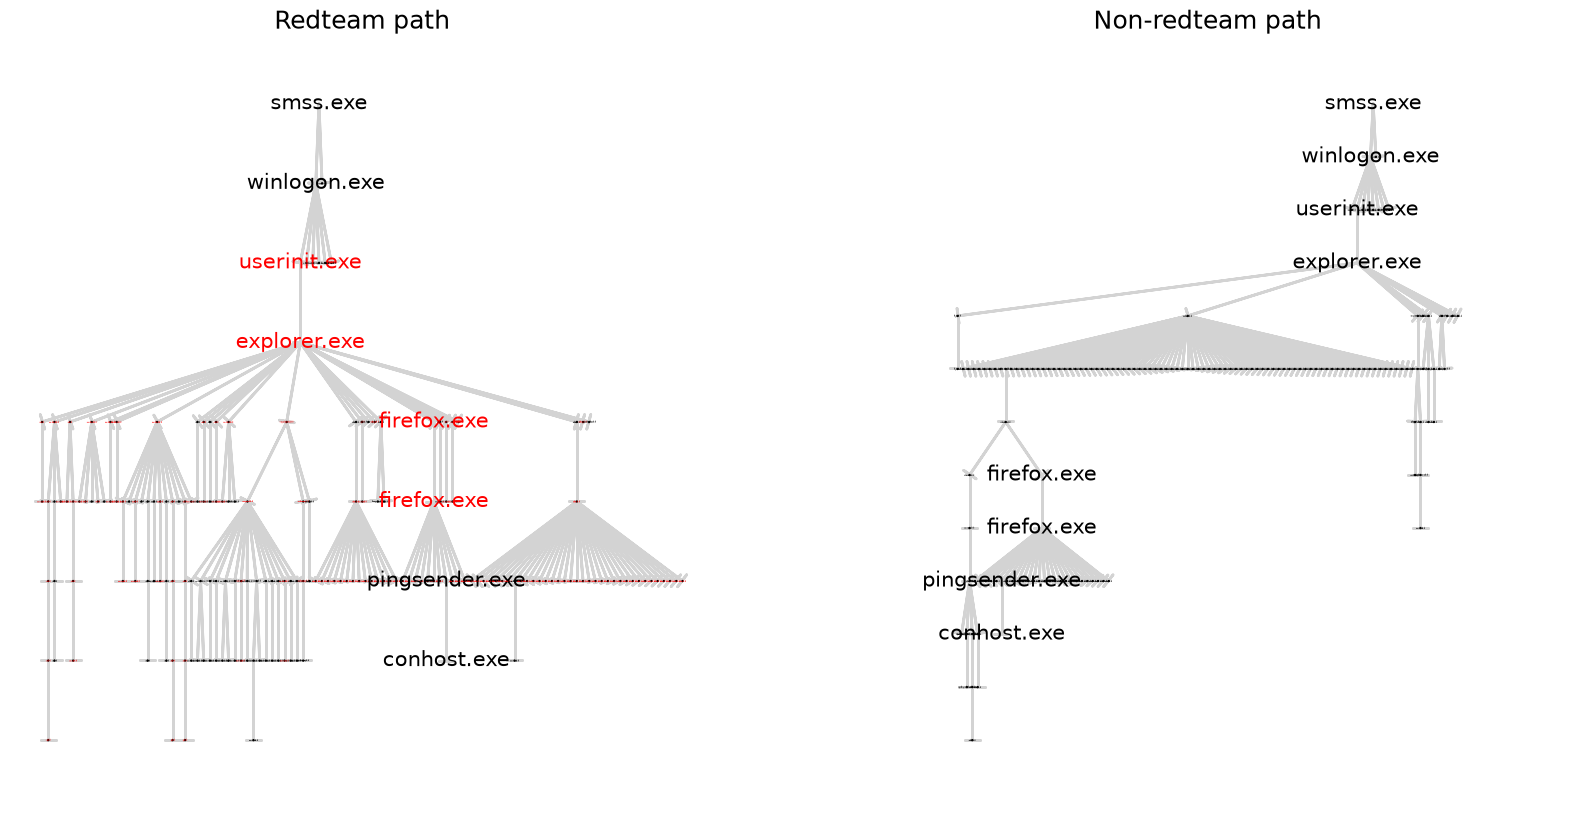

In [24]:
## plot best result
sg_red = acme_get_bfs_subtree(Trees, _trees[best_pair[0]], _roots[best_pair[0]]) 
sg_black = acme_get_bfs_subtree(Trees, _trees[best_pair[1]], _roots[best_pair[1]]) 
_sg_red = igio.igraph_to_treedata(sg_red, phi_name='uid')
_sg_black = igio.igraph_to_treedata(sg_black, phi_name='uid')
match = nwt.align_trees_algorithm1(_sg_red, _sg_black, w=weight)
plot_path((sg_red,sg_black), match.path_internal, margin=(0,.14))
print('Score:',match.score)

In [63]:
## PLOT in Embed space


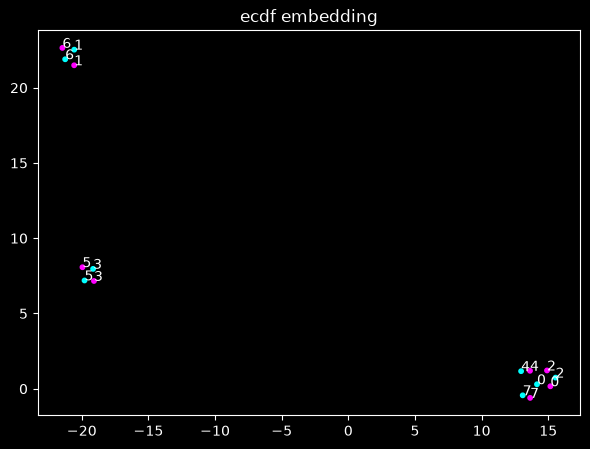

In [51]:
import umap
path = [x[0] for x in match.path_internal]
X = [embedding_ecdf[sg_red.vs[i]['uid']] for i in path]

path = [x[0] for x in match.path_internal]
X.extend([embedding_ecdf[sg_red.vs[i]['uid']] for i in path])

l = len(path)
c = np.repeat([0,1],l)

reducer = umap.UMAP(n_neighbors=3, metric='manhattan', min_dist=.25, spread=1.5)
embedding = reducer.fit_transform(np.array(X))

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=c, cmap='cool');
ax.set_title('ecdf embedding')
s = np.tile(np.arange(l),2)
for i in range(embedding.shape[0]):
    ax.annotate(s[i], (embedding[i, 0], embedding[i, 1]))

In [187]:
angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
offx = 3*np.cos(angles)
offy = 3*np.sin(angles)

offx = 2*np.array([1,1,.5,.5,.5,0,0,1,-1,0,-.5,-.5,0,.25,-1,-.5])
offy = 3*np.array([1,1,1,1,1,1,1,1,-1,-1.5,-1,-1,-1,-1,-1,-1])


In [188]:
path = [x[0] for x in match.path_internal]
l = len(path)
s = np.tile(np.arange(l),2)
cl = np.repeat(['red','blue'],l)
l = sg_red.vcount()
path.extend([x[1]+l for x in match.path_internal])


/work/home/fcthebe/.conda/envs/complexnetworks/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


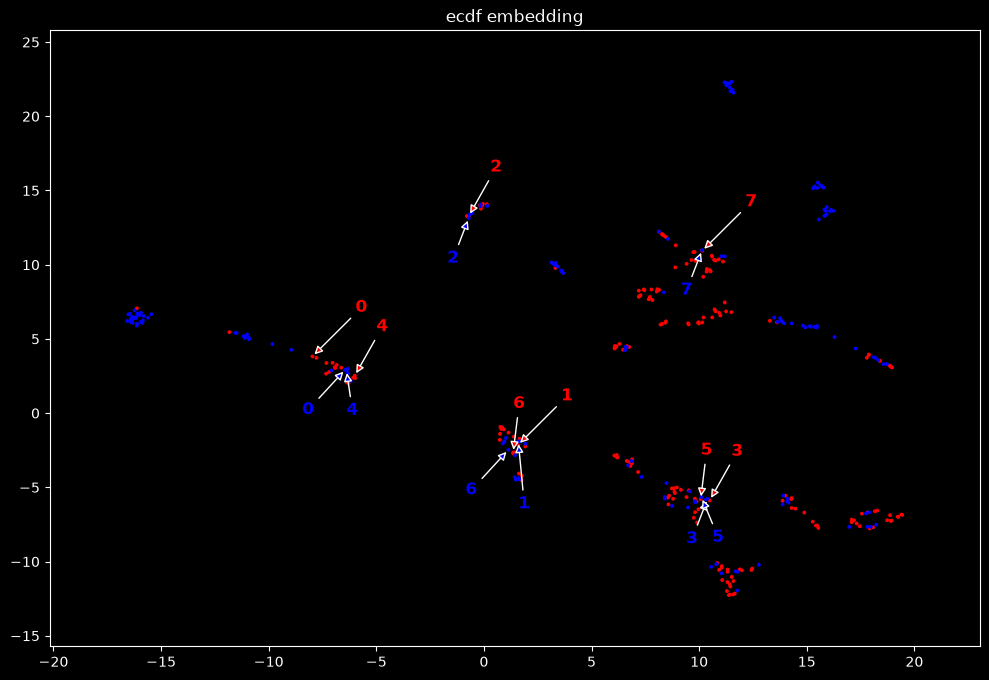

In [189]:
X = [embedding_ecdf[x] for x in sg_red.vs['uid']]
X.extend([embedding_ecdf[x] for x in sg_black.vs['uid']])
c = np.concatenate( [np.repeat('red',sg_red.vcount()), np.repeat('blue',sg_black.vcount())] )
reducer = umap.UMAP(n_neighbors=7, metric='manhattan', min_dist=.25, spread=1.5, random_state=123)
embedding = reducer.fit_transform(np.array(X))

#plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(embedding[:, 0], embedding[:, 1], s=3, c=c );
ax.set_title('ecdf embedding')

for i in range(len(path)):
    # 3. AJOUT DE L'ANNOTATION AVEC FLÈCHE
    ax.annotate(
        s[i],       # Le texte de l'annotation
        xy=(embedding[path[i], 0], embedding[path[i], 1]),          # Coordonnées (x, y) de la pointe de la flèche
        xytext=(embedding[path[i], 0] + offx[i], embedding[path[i], 1] + offy[i]), # Coordonnées (x, y) du texte (décalé pour laisser de la place)
        arrowprops=dict(
            facecolor=cl[i],          # Couleur de remplissage de la flèche
            arrowstyle="-|>",            # Style de la flèche (ex: "->", "-|>", "fancy")
            lw=1.0                      # Épaisseur de la ligne (line width)
        ),
        fontsize=12,
        color=cl[i],
        fontweight="bold"
    )

ax.margins(.1)

In [ ]:
offx = [1,1,.5,.5,0,0,0,1,-1,-1,-.5,-.5,0,.25,-1,-1]
